In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

In [26]:
df = pd.read_csv('/content/Dengue-Dataset.csv')

In [27]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(r"[()/%]", "", regex=True)
    .str.replace(" ", "_")
)

print(df.columns)

Index(['gender', 'age', 'hemoglobingdl', 'neutrophils', 'lymphocytes',
       'monocytes', 'eosinophils', 'rbc', 'hct', 'mcvfl', 'mchpg', 'mchcgdl',
       'rdw-cv', 'total_platelet_countcumm', 'mpvfl', 'pdw', 'pct',
       'total_wbc_countcumm', 'result'],
      dtype='object')


In [28]:
# Final renaming
df.rename(columns={
    'total_platelet_countcumm': 'platelet_count',
    'total_wbc_countcumm': 'wbc_count',
    'rdw-cv': 'rdw_cv'
}, inplace=True)

In [29]:
df.columns

Index(['gender', 'age', 'hemoglobingdl', 'neutrophils', 'lymphocytes',
       'monocytes', 'eosinophils', 'rbc', 'hct', 'mcvfl', 'mchpg', 'mchcgdl',
       'rdw_cv', 'platelet_count', 'mpvfl', 'pdw', 'pct', 'wbc_count',
       'result'],
      dtype='object')

Feature Engineering (Important)

In [31]:
df['nlr'] = df['neutrophils'] / (df['lymphocytes'] + 1e-5)
df['platelet_wbc_ratio'] = df['platelet_count'] / (df['wbc_count'] + 1e-5)
df['platelet_hct_ratio'] = df['platelet_count'] / (df['hct'] + 1e-5)

In [32]:
le = LabelEncoder()
df['result'] = le.fit_transform(df['result'])

In [33]:
X = df.drop('result', axis=1)
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [34]:
num_features = X.select_dtypes(include=['int64','float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features)
])

In [35]:
smote = SMOTE(random_state=42)

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

final_pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('smote', smote),
    ('model', xgb)
])

In [36]:
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'hemoglobingdl', 'neutrophils', 'lymphocytes', 'monocytes',
       'eosinophils', 'rbc', 'hct', 'mcvfl', 'mchpg', 'mchcgdl', 'rdw_cv',
       'platelet_count', 'mpvfl', 'pdw', 'pct', 'wbc_count', 'nlr',
       'p...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=600, n_jobs=None,
                               num_parallel_tree=None, ...))])

              precision    recall  f1-score   support

           0       0.55      0.45      0.49        96
           1       0.77      0.83      0.80       209

    accuracy                           0.71       305
   macro avg       0.66      0.64      0.65       305
weighted avg       0.70      0.71      0.70       305

ROC-AUC: 0.6750647926634769


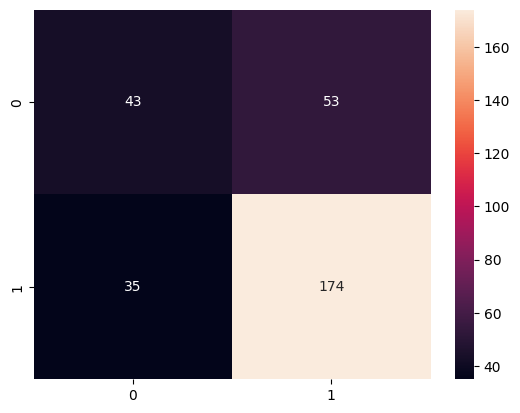

In [37]:
y_prob = final_pipeline.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

In [38]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    final_pipeline,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)

print("Cross-Validation ROC-AUC:", cv_scores.mean())

Cross-Validation ROC-AUC: 0.6779278869078109


In [71]:
df = pd.read_csv('/content/Dengue diseases dataset.csv')

In [72]:
df.columns

Index(['Age', 'Sex', 'Haemoglobin', 'WBC Count', 'Differential Count',
       'RBC PANEL', 'Platelet Count', 'PDW', 'Final Output'],
      dtype='object')

In [73]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

print(df.columns)

Index(['age', 'sex', 'haemoglobin', 'wbc_count', 'differential_count',
       'rbc_panel', 'platelet_count', 'pdw', 'final_output'],
      dtype='object')


In [74]:
df.rename(columns={'final_output': 'result'}, inplace=True)

In [75]:
le = LabelEncoder()
df['result'] = le.fit_transform(df['result'])

In [76]:
X2 = df.drop('result', axis=1)
y2 = df['result']

In [77]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X2, y2,
    test_size=0.2,
    stratify=y2,
    random_state=42
)

In [78]:
num_features = X2.select_dtypes(include=['int64','float64']).columns
cat_features = X2.select_dtypes(include=['object']).columns

print("Numeric:", num_features)
print("Categorical:", cat_features)

Numeric: Index(['age', 'haemoglobin', 'wbc_count', 'differential_count', 'rbc_panel',
       'platelet_count', 'pdw'],
      dtype='object')
Categorical: Index(['sex'], dtype='object')


In [79]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features)
])

In [80]:
smote = SMOTE(random_state=42)

In [81]:
scale_pos_weight = len(y_train_2[y_train_2==0]) / len(y_train_2[y_train_2==1])

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

In [82]:
final_pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('smote', smote),
    ('model', xgb)
])

In [83]:
final_pipeline.fit(X_train_2, y_train_2)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:41:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'haemoglobin', 'wbc_count', 'differential_count', 'rbc_panel',
       'platelet_count', 'pdw'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [88]:
y_prob2 = final_pipeline.predict_proba(X_test_2)
y_pred2 = final_pipeline.predict(X_test_2)

print(classification_report(y_test_2, y_pred2, zero_division=0))

if y_prob2.shape[1] == 2:
    print("ROC-AUC:", roc_auc_score(y_test_2, y_prob2[:,1]))
else:
    print("ROC-AUC:", roc_auc_score(y_test_2, y_prob2, multi_class='ovr'))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        64
           1       0.98      0.97      0.97       134
           2       0.00      0.00      0.00         3

    accuracy                           0.97       201
   macro avg       0.65      0.66      0.66       201
weighted avg       0.97      0.97      0.97       201

ROC-AUC: 0.8958924159042968


In [90]:
joblib.dump(final_pipeline, "dengue_new_dataset_model.pkl")

['dengue_new_dataset_model.pkl']